In [1]:
# ===============================
# TASK 4 — U-Net Training for Segmentation
# ===============================

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# GPU/CPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths (same as your previous tasks)
TRAIN_IMG_DIR = "/content/drive/MyDrive/coco20k/train/images"
TRAIN_MASK_DIR = "/content/drive/MyDrive/coco20k/train/masks"
VAL_IMG_DIR   = "/content/drive/MyDrive/coco20k/val/images"
VAL_MASK_DIR  = "/content/drive/MyDrive/coco20k/val/masks"

IMG_SIZE = 256


Using device: cpu


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [5]:
import os
print(os.listdir("/content/drive"))


['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']


In [7]:
print(os.listdir("/content/drive/MyDrive/coco20k"))


['images', 'masks', 'train', 'val', 'task5_predictions']


In [8]:
TRAIN_IMG_DIR = "/content/drive/MyDrive/coco20k/train/images"
TRAIN_MASK_DIR = "/content/drive/MyDrive/coco20k/train/masks"

VAL_IMG_DIR   = "/content/drive/MyDrive/coco20k/val/images"
VAL_MASK_DIR  = "/content/drive/MyDrive/coco20k/val/masks"


In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [10]:
import os

print(os.listdir("/content/drive/MyDrive/coco20k/train"))
print(os.listdir("/content/drive/MyDrive/coco20k/val"))


['images', 'masks']
['images', 'masks']


In [12]:
TRAIN_IMG_DIR = "/content/drive/MyDrive/coco20k/train/images"
TRAIN_MASK_DIR = "/content/drive/MyDrive/coco20k/train/masks"

VAL_IMG_DIR   = "/content/drive/MyDrive/coco20k/val/images"
VAL_MASK_DIR  = "/content/drive/MyDrive/coco20k/val/masks"

import os

print("Train folder:", os.listdir("/content/drive/MyDrive/coco20k/train"))
print("Val folder:", os.listdir("/content/drive/MyDrive/coco20k/val"))


Train folder: ['images', 'masks']
Val folder: ['images', 'masks']


In [13]:
import os
import cv2
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 256

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=256, augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment = augment

        self.files = sorted(os.listdir(img_dir))
        self.files = [f for f in self.files if f.lower().endswith((".jpg",".jpeg",".png"))]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        img_path = os.path.join(self.img_dir, img_name)

        mask_name = img_name.rsplit(".",1)[0] + ".png"
        mask_path = os.path.join(self.mask_dir, mask_name)

        # read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        # normalize
        img = img.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)

        # augment
        if self.augment and random.random() > 0.5:
            img = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()

        # CHW format
        img = np.transpose(img, (2,0,1))
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

# create datasets
train_dataset = SegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment=True)
val_dataset   = SegmentationDataset(VAL_IMG_DIR, VAL_MASK_DIR, augment=False)

# create loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


Train samples: 29256
Val samples: 7334


In [14]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(3, 64)
        self.d2 = DoubleConv(64, 128)
        self.d3 = DoubleConv(128, 256)
        self.d4 = DoubleConv(256, 512)
        self.bott = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.u4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.u3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.u2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.u1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.d1(x)
        p1 = nn.MaxPool2d(2)(c1)

        c2 = self.d2(p1)
        p2 = nn.MaxPool2d(2)(c2)

        c3 = self.d3(p2)
        p3 = nn.MaxPool2d(2)(c3)

        c4 = self.d4(p3)
        p4 = nn.MaxPool2d(2)(c4)

        c5 = self.bott(p4)

        u4 = self.up4(c5)
        c6 = self.u4(torch.cat([u4, c4], dim=1))

        u3 = self.up3(c6)
        c7 = self.u3(torch.cat([u3, c3], dim=1))

        u2 = self.up2(c7)
        c8 = self.u2(torch.cat([u2, c2], dim=1))

        u1 = self.up1(c8)
        c9 = self.u1(torch.cat([u1, c1], dim=1))

        return self.out(c9)


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet().to(device)

bce = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - ((2 * inter + smooth) / (union + smooth))


In [18]:
# SPEED MODE ON

EPOCHS = 3

train_dataset = SegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment=True)
val_dataset   = SegmentationDataset(VAL_IMG_DIR, VAL_MASK_DIR, augment=False)

train_dataset.files = train_dataset.files[:3000]  # FAST TRAINING
val_dataset.files   = val_dataset.files[:500]

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)


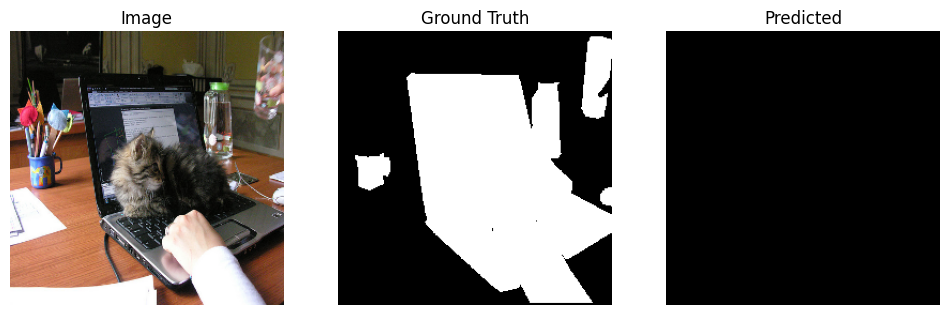

In [19]:
import matplotlib.pyplot as plt
model.eval()

with torch.no_grad():
    img, mask = val_dataset[0]
    img_t = img.unsqueeze(0).to(device)

    pred = torch.sigmoid(model(img_t))[0,0].cpu().numpy()
    pred_bin = (pred > 0.5).astype("uint8")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask[0], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_bin, cmap="gray")
plt.title("Predicted")
plt.axis("off")

plt.show()


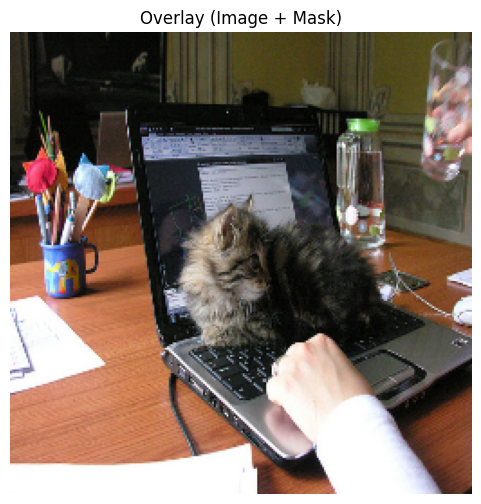

In [21]:
import cv2
import numpy as np

# Overlay (image + predicted mask)
image_np = (img.permute(1,2,0).numpy() * 255).astype("uint8")

mask_color = np.zeros_like(image_np)
mask_color[:,:,0] = pred_bin * 255   # red mask

overlay = cv2.addWeighted(image_np, 1, mask_color, 0.5, 0)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Overlay (Image + Mask)")
plt.axis("off")
plt.show()


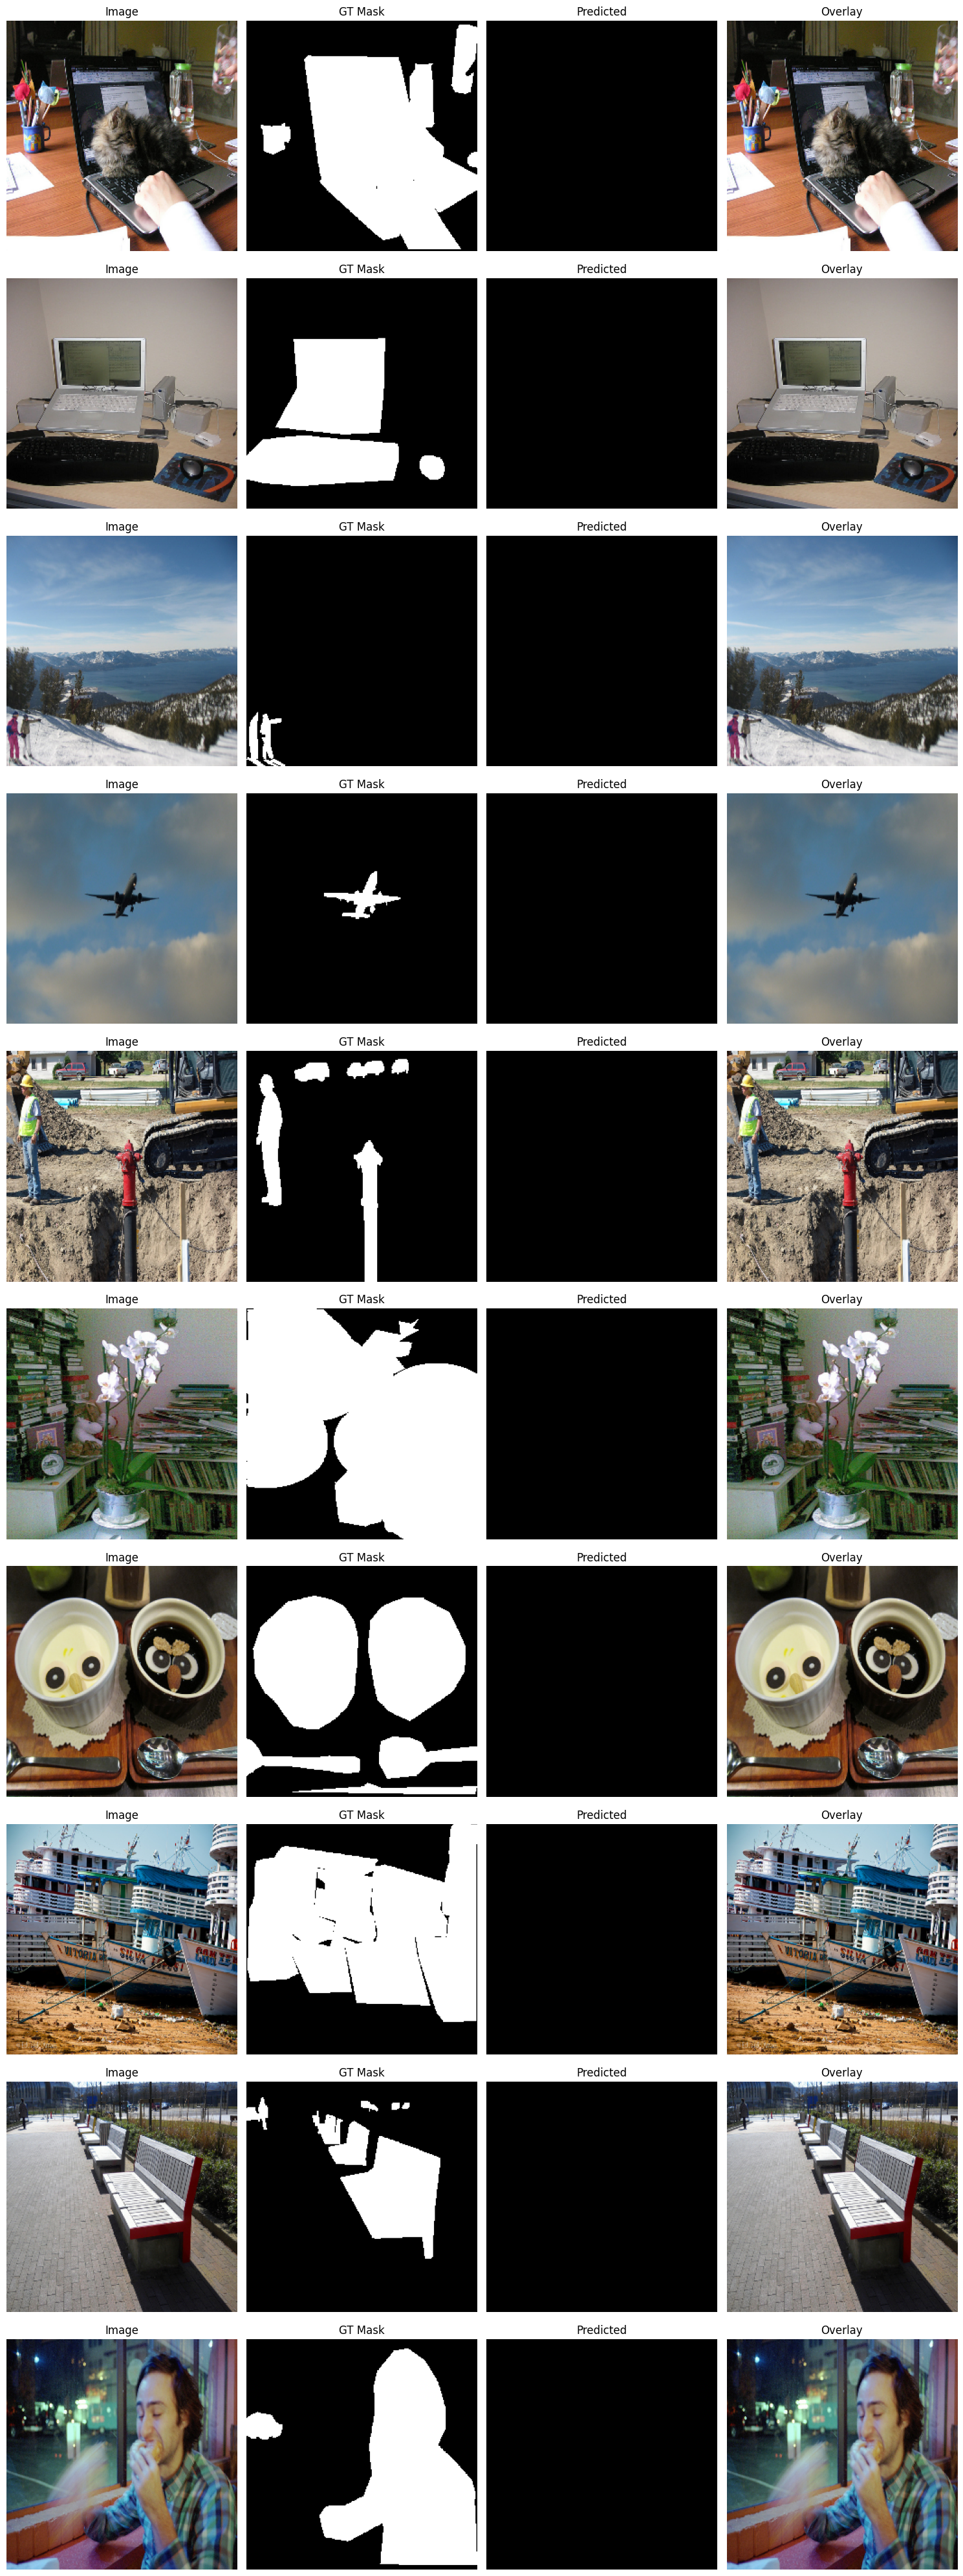

In [22]:
plt.figure(figsize=(15,40))
k = 1

for i in range(10):
    img, mask = val_dataset[i]
    img_t = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(img_t))[0,0].cpu().numpy()

    pred_bin = (pred > 0.5).astype("uint8")

    # overlay banaao
    base = (img.permute(1,2,0).numpy()*255).astype("uint8")
    over_mask = np.zeros_like(base)
    over_mask[:,:,0] = pred_bin * 255
    overlay = cv2.addWeighted(base, 1, over_mask, 0.5, 0)

    # 4 images: Image | GT | Pred | Overlay
    plt.subplot(10,4,k); k+=1
    plt.imshow(base); plt.title("Image"); plt.axis("off")

    plt.subplot(10,4,k); k+=1
    plt.imshow(mask[0], cmap="gray"); plt.title("GT Mask"); plt.axis("off")

    plt.subplot(10,4,k); k+=1
    plt.imshow(pred_bin, cmap="gray"); plt.title("Predicted"); plt.axis("off")

    plt.subplot(10,4,k); k+=1
    plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")

plt.tight_layout()
plt.savefig("/content/task4_predictions.png")
plt.show()


In [24]:
torch.save(model.state_dict(), "/content/drive/MyDrive/unet_task4_final.pth")
print("Correct PyTorch model saved!")


Correct PyTorch model saved!
